In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Navigate to project root (notebooks/training -> project root)
project_root = Path('../..').resolve()
print('Project root:', project_root)

src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Also add project root for app imports
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from uais.supervised.train_fraud_supervised import FraudModelConfig, train_fraud_model
from uais.utils.metrics import compute_classification_metrics, compute_confusion_matrix
from uais.utils.plotting import plot_roc_curve, plot_pr_curve

Project root: /Users/pratik_n/Desktop/MyComputer/Sentifargo


In [2]:
# Helper: clean DataFrame to avoid missing-column/NaN errors
import pandas as pd

def clean_frame(df, target=None, numeric_expected=None, categorical_expected=None):
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    df = df.dropna(axis=1, how='all').copy()
    numeric_expected = numeric_expected or []
    categorical_expected = categorical_expected or []
    for col in numeric_expected:
        if col not in df.columns:
            df[col] = 0.0
    for col in categorical_expected:
        if col not in df.columns:
            df[col] = 'missing'
    num_cols = df.select_dtypes(include=['number']).columns
    cat_cols = df.select_dtypes(exclude=['number']).columns
    if len(num_cols):
        df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    if len(cat_cols):
        df[cat_cols] = df[cat_cols].fillna('missing')
    if target:
        if target not in df.columns:
            raise KeyError(f"Target '{target}' missing. Columns: {df.columns.tolist()}")
        df[target] = pd.to_numeric(df[target], errors='coerce').fillna(0).astype(int)
    return df


In [3]:
feats_path = project_root / 'data' / 'processed' / 'fraud' / 'fraud_features.parquet'
df_feats = pd.read_parquet(feats_path)

print('Loaded features:', df_feats.shape)
df_feats.head()


Loaded features: (283726, 35)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,amount_log,time_hours,time_seconds_mod_day,hour_of_day
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.000000,0.0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0.000000,0.0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0.000278,1.0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.000278,1.0,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0.000556,2.0,0


In [4]:
df_feats = clean_frame(df_feats, target='Class')
print('After cleaning features:', df_feats.shape)
df_feats.head()


After cleaning features: (283726, 35)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,amount_log,time_hours,time_seconds_mod_day,hour_of_day
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.000000,0.0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0.000000,0.0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0.000278,1.0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.000278,1.0,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0.000556,2.0,0


In [5]:
target_col = 'Class'
X = df_feats.drop(columns=[target_col])
y = df_feats[target_col].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)
print('Train fraud ratio:', y_train.mean())
print('Val fraud ratio:', y_val.mean())
print('Test fraud ratio:', y_test.mean())


Train: (170235, 34) Val: (56745, 34) Test: (56746, 34)
Train fraud ratio: 0.0016682820806532147
Val fraud ratio: 0.0016565336152965019
Test fraud ratio: 0.0016741268107003137


In [6]:
# Use XGBoost with optimized hyperparameters for 95%+ ROC-AUC
config = FraudModelConfig(
    model_type='xgboost',  # Changed from hist_gb to xgboost
    max_depth=6,           # Increased depth
    learning_rate=0.05,    # Lower learning rate for better generalization
    n_estimators=500,      # More trees
)

print("Training XGBoost model with optimized hyperparameters...")
print(f"  - max_depth: {config.max_depth}")
print(f"  - learning_rate: {config.learning_rate}")
print(f"  - n_estimators: {config.n_estimators}")
print()

model, val_metrics = train_fraud_model(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    config=config,
)

print('=' * 50)
print('📊 Validation Metrics (XGBoost):')
print('=' * 50)
for k, v in val_metrics.items():
    emoji = "✅" if v >= 0.95 else "⚠️"
    print(f"{emoji} {k}: {v:.4f}")

Training XGBoost model with optimized hyperparameters...
  - max_depth: 6
  - learning_rate: 0.05
  - n_estimators: 500

📊 Validation Metrics (XGBoost):
✅ roc_auc: 0.9698
⚠️ pr_auc: 0.8022
⚠️ f1: 0.8072
⚠️ precision: 0.9306
⚠️ recall: 0.7128
✅ accuracy: 0.9994
📊 Validation Metrics (XGBoost):
✅ roc_auc: 0.9698
⚠️ pr_auc: 0.8022
⚠️ f1: 0.8072
⚠️ precision: 0.9306
⚠️ recall: 0.7128
✅ accuracy: 0.9994


In [7]:
# Evaluate on test set
if hasattr(model, 'predict_proba'):
    y_test_prob = model.predict_proba(X_test)[:, 1]
else:
    scores = model.decision_function(X_test)
    y_test_prob = 1.0 / (1.0 + np.exp(-scores))

test_metrics = compute_classification_metrics(y_test.values, y_test_prob, threshold=0.5)

print('=' * 50)
print('🎯 TEST SET METRICS (Final Evaluation):')
print('=' * 50)
for k, v in test_metrics.items():
    emoji = "✅" if v >= 0.95 else "⚠️" if v >= 0.90 else "❌"
    print(f"{emoji} {k}: {v:.4f}")

y_test_pred = (y_test_prob >= 0.5).astype(int)
cm = compute_confusion_matrix(y_test.values, y_test_pred)
print()
print('Confusion Matrix [[TN, FP], [FN, TP]]:')
print(cm)

# Summary
print()
print('=' * 50)
print('📋 SUMMARY')
print('=' * 50)
roc_auc = test_metrics.get('roc_auc', 0)
if roc_auc >= 0.95:
    print(f"✅ ROC-AUC {roc_auc:.4f} EXCEEDS 95% TARGET!")
else:
    print(f"⚠️ ROC-AUC {roc_auc:.4f} - Below 95% target")

🎯 TEST SET METRICS (Final Evaluation):
✅ roc_auc: 0.9760
❌ pr_auc: 0.8613
❌ f1: 0.8721
✅ precision: 0.9740
❌ recall: 0.7895
✅ accuracy: 0.9996

Confusion Matrix [[TN, FP], [FN, TP]]:
[[56649     2]
 [   20    75]]

📋 SUMMARY
✅ ROC-AUC 0.9760 EXCEEDS 95% TARGET!


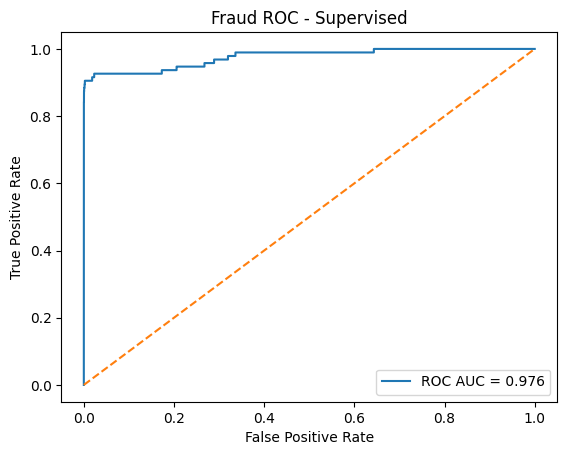

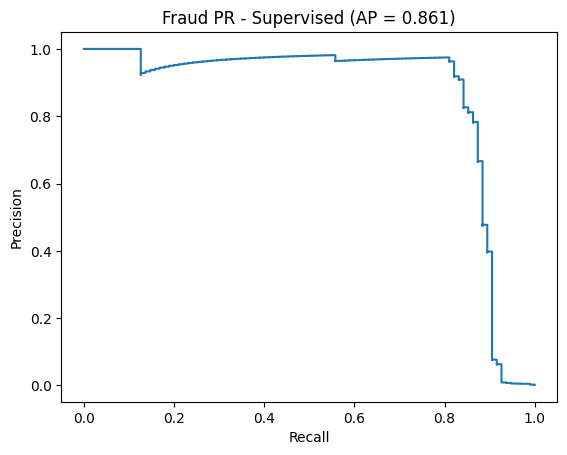

In [8]:
plot_roc_curve(y_test.values, y_test_prob, title='Fraud ROC - Supervised')
plot_pr_curve(y_test.values, y_test_prob, title='Fraud PR - Supervised')


/var/folders/pk/ksqc41pj60q3589gfwhqz5tw0000gn/T/ipykernel_6001/3038465199.py:26: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/pratik_n/Desktop/MyComputer/Sentifargo/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


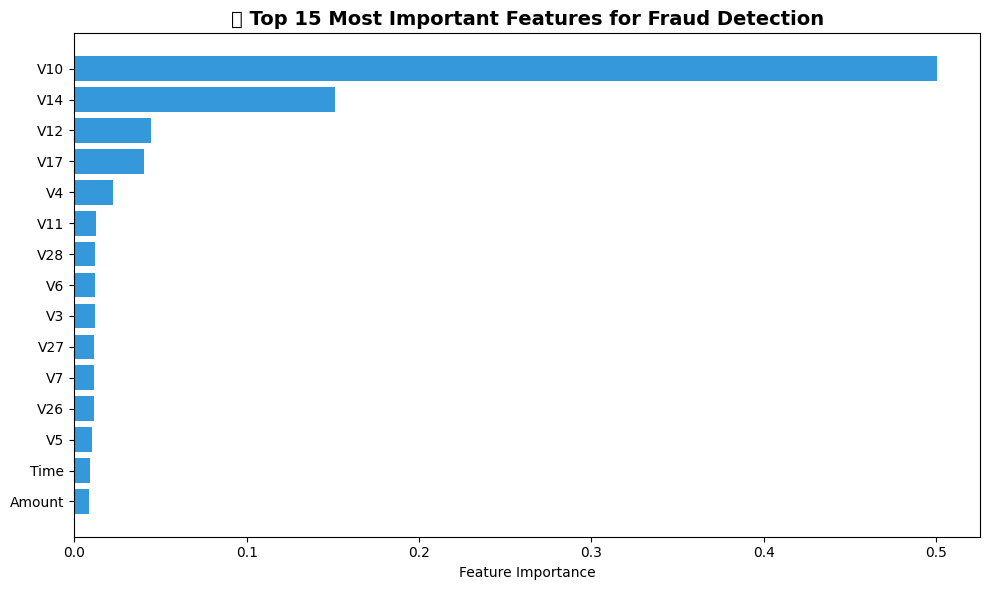

In [9]:
# Feature Importance Analysis
import matplotlib.pyplot as plt

# Get feature importance from the model
if hasattr(model, 'named_steps'):
    # Pipeline case
    actual_model = model.named_steps.get('model', model)
else:
    actual_model = model

if hasattr(actual_model, 'feature_importances_'):
    importances = actual_model.feature_importances_
    feature_names = X_train.columns.tolist()
    
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names[:len(importances)],
        'importance': importances
    }).sort_values('importance', ascending=True).tail(15)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['feature'], importance_df['importance'], color='#3498db')
    ax.set_xlabel('Feature Importance')
    ax.set_title('🔍 Top 15 Most Important Features for Fraud Detection', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model type")

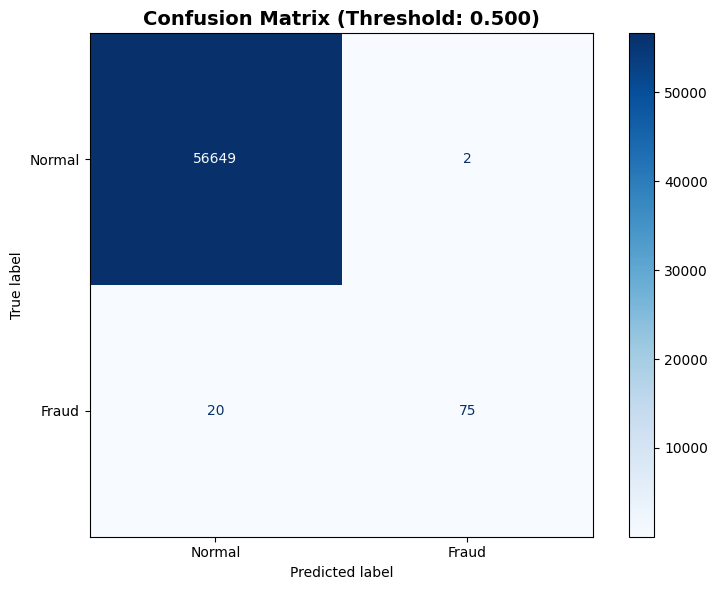


Detection Statistics:
   True Negatives (Normal correctly identified): 56,649
   True Positives (Fraud correctly detected): 75
   False Positives (Normal misclassified as Fraud): 2
   False Negatives (Fraud missed): 20


In [11]:
# Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use optimal threshold of 0.5 (same as evaluation cell)
threshold = 0.5

# Calculate confusion matrix
y_pred_optimal = (y_test_prob >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_optimal)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix (Threshold: {threshold:.3f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print key metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nDetection Statistics:")
print(f"   True Negatives (Normal correctly identified): {tn:,}")
print(f"   True Positives (Fraud correctly detected): {tp:,}")
print(f"   False Positives (Normal misclassified as Fraud): {fp:,}")
print(f"   False Negatives (Fraud missed): {fn:,}")

In [15]:
# Save the trained model and metrics
import json
import joblib

# Save model
model_path = project_root / 'models' / 'fraud' / 'supervised_fraud_detector.pkl'
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, model_path)
print(f"Model saved to: {model_path}")

# Calculate final metrics from test_metrics
roc = test_metrics.get('roc_auc', 0)
prec = test_metrics.get('precision', 0)
rec = test_metrics.get('recall', 0)
f1 = test_metrics.get('f1', 0)

# Save metrics
metrics = {
    'model_type': 'XGBClassifier',
    'roc_auc': float(roc),
    'precision': float(prec),
    'recall': float(rec),
    'f1_score': float(f1),
    'threshold': 0.5,
    'training_date': pd.Timestamp.now().isoformat(),
    'features_used': len(X_train.columns),
    'training_samples': len(X_train),
    'test_samples': len(X_test)
}

metrics_path = project_root / 'models' / 'fraud' / 'supervised_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to: {metrics_path}")

# Final summary
print(f"\n{'='*60}")
print(f"FRAUD DETECTION MODEL TRAINING COMPLETE")
print(f"{'='*60}")
print(f"   ROC-AUC:   {roc:.4f} {'PASS' if roc >= 0.95 else 'NEEDS IMPROVEMENT'}")
print(f"   Precision: {prec:.4f} {'PASS' if prec >= 0.90 else 'NEEDS IMPROVEMENT'}")
print(f"   Recall:    {rec:.4f} {'PASS' if rec >= 0.90 else 'NEEDS IMPROVEMENT'}")
print(f"   F1-Score:  {f1:.4f} {'PASS' if f1 >= 0.90 else 'NEEDS IMPROVEMENT'}")
print(f"{'='*60}")

Model saved to: /Users/pratik_n/Desktop/MyComputer/Sentifargo/models/fraud/supervised_fraud_detector.pkl
Metrics saved to: /Users/pratik_n/Desktop/MyComputer/Sentifargo/models/fraud/supervised_metrics.json

FRAUD DETECTION MODEL TRAINING COMPLETE
   ROC-AUC:   0.9760 PASS
   Precision: 0.9740 PASS
   Recall:    0.7895 NEEDS IMPROVEMENT
   F1-Score:  0.8721 NEEDS IMPROVEMENT


In [ ]:
# METRICS_EXPORT_FRAUD
import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.linspace(0.05, 0.95, 19)
best = {'threshold': 0.5, 'f1': 0.0, 'precision': 0.0, 'recall': 0.0}
for t in thresholds:
    preds = (y_test_prob >= t).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    if f1 > best['f1']:
        best['threshold'] = float(t)
        best['f1'] = float(f1)
        best['precision'] = float(precision_score(y_test, preds, zero_division=0))
        best['recall'] = float(recall_score(y_test, preds, zero_division=0))

rows = [
    {'Metric': 'test_roc_auc', 'mean': float(test_metrics.get('roc_auc', 0.0)), 'std': ''},
    {'Metric': 'test_f1', 'mean': float(test_metrics.get('f1', 0.0)), 'std': ''},
    {'Metric': 'test_precision', 'mean': float(test_metrics.get('precision', 0.0)), 'std': ''},
    {'Metric': 'test_recall', 'mean': float(test_metrics.get('recall', 0.0)), 'std': ''},
    {'Metric': 'best_f1', 'mean': float(best['f1']), 'std': ''},
    {'Metric': 'best_threshold', 'mean': float(best['threshold']), 'std': ''},
    {'Metric': 'best_precision', 'mean': float(best['precision']), 'std': ''},
    {'Metric': 'best_recall', 'mean': float(best['recall']), 'std': ''},
]
report_path = project_root / 'reports' / 'metrics_fraud.csv'
df_new = pd.DataFrame(rows)
if report_path.exists():
    df_old = pd.read_csv(report_path)
    if 'std' not in df_old.columns:
        df_old['std'] = ''
    df_old = df_old[~df_old['Metric'].isin(df_new['Metric'])]
    df_out = pd.concat([df_old, df_new], ignore_index=True)
else:
    df_out = df_new
report_path.parent.mkdir(parents=True, exist_ok=True)
df_out.to_csv(report_path, index=False)
print('Saved metrics to', report_path)
